# Olist: Delivery Time Prediction Model

## 1. Data preparation

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

clean = pd.read_parquet("../data/clean/clean.parquet")
print(clean.shape)

(96164, 35)


## 2. Time-based split

In [30]:
clean = clean.sort_values('order_purchase_timestamp').reset_index(drop=True)

split_point = int(len(clean)*0.8)
train = clean.iloc[:split_point]
test = clean.iloc[split_point:]

print("Train size: ", len(train))
print("Test size: ", len(test))
print("Train until: ", train['order_purchase_timestamp'].max())
print("Test from: ", test['order_purchase_timestamp'].min())
print("Test until: ", test['order_purchase_timestamp'].max())


Train size:  76931
Test size:  19233
Train until:  2018-05-27 11:44:23
Test from:  2018-05-27 11:55:26
Test until:  2018-08-29 15:00:37


Split 2018-05-27: train 76,931, test 19,233 (Jun–Aug 2018 — fastest period, drift check). No winter months in test.

## 3. Baselines on test

In [31]:
naive_pred = train['delivery_days'].mean()
mae_naive = (test['delivery_days'] - naive_pred).abs().mean()
mae_olist = test['estimation_error'].abs().mean()

print("Naive prediction: ", naive_pred)
print("Naive MAE: ", mae_naive)
print("Olist MAE: ", mae_olist)


Naive prediction:  12.76100661631852
Naive MAE:  6.187670982060636
Olist MAE:  13.168304476680705


Baselines on test: naive (train mean 12.76) gives MAE 6.19, Olist estimate gives 13.17. Target for the model below 6.19.

## 4. RandomForest

In [32]:
FEATURES = ['purchase_month', 'purchase_day_of_week', 'purchase_year', 'total_price',
            'total_freight', 'quantity_items', 'same_state', 'product_weight_g', 'volume_cm3',
            'customer_state_code', 'seller_state_code', 'product_category_name_code', 'customer_city_code']


print("Missing: ", [c for c in FEATURES if c not in clean.columns])

Missing:  []


In [33]:
TARGET = 'delivery_days'

X_train = train[FEATURES]
Y_train = train[TARGET]
X_test = test[FEATURES]
Y_test = test[TARGET]

print(X_train.shape, X_test.shape)

(76931, 13) (19233, 13)


In [34]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, Y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [35]:
pred = model_rf.predict(X_test)

mae_model_rf = mean_absolute_error(Y_test, pred)
r2_model_rf = r2_score(Y_test, pred)

print("R2 score Random Forest: ", r2_model_rf)
print("MAE score Random Forest: ", mae_model_rf)
print("MAE naive: ", mae_naive)
print("MAE Olist: ", mae_olist)

R2 score Random Forest:  -0.1938134025811884
MAE score Random Forest:  4.752435103818001
MAE naive:  6.187670982060636
MAE Olist:  13.168304476680705


## 5. Error analysis

In [36]:
errors_rf = (Y_test - pred).abs()
print(errors_rf.describe().round(2))
print("Errors > 15 days:", (errors_rf > 15).sum())

count    19233.00
mean         4.75
std          3.88
min          0.00
25%          2.02
50%          3.96
75%          6.51
max         48.40
Name: delivery_days, dtype: float64
Errors > 15 days: 373


Median 4.0 days, 75% of orders within 6.5 days. Only 372 orders (under 2%) have errors above 15 days but their squared errors are large enough to push R2 below zero, while MAE stays good (4.76 vs 6.19 naive). The model cannot predict rare long delays.

These delays need a separate model which will predict which orders are at risk of delay.

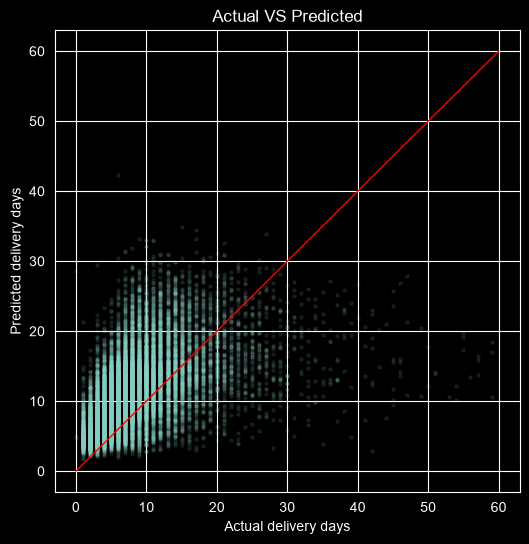

In [38]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, pred, alpha=0.1, s = 5)
plt.plot([0,60],[0,60], color='Red', linewidth = 1)
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual VS Predicted")
plt.show()


Typical deliveries sit on the diagonal. Delays of 30+ days are predicted as 10–20 and model can't see them coming.

## 6. Feature importances

In [37]:
importances = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.round(3))

same_state                    0.166
total_freight                 0.127
total_price                   0.111
volume_cm3                    0.108
product_weight_g              0.099
customer_state_code           0.092
purchase_month                0.076
product_category_name_code    0.067
purchase_day_of_week          0.061
customer_city_code            0.039
seller_state_code             0.024
purchase_year                 0.022
quantity_items                0.008
dtype: float64


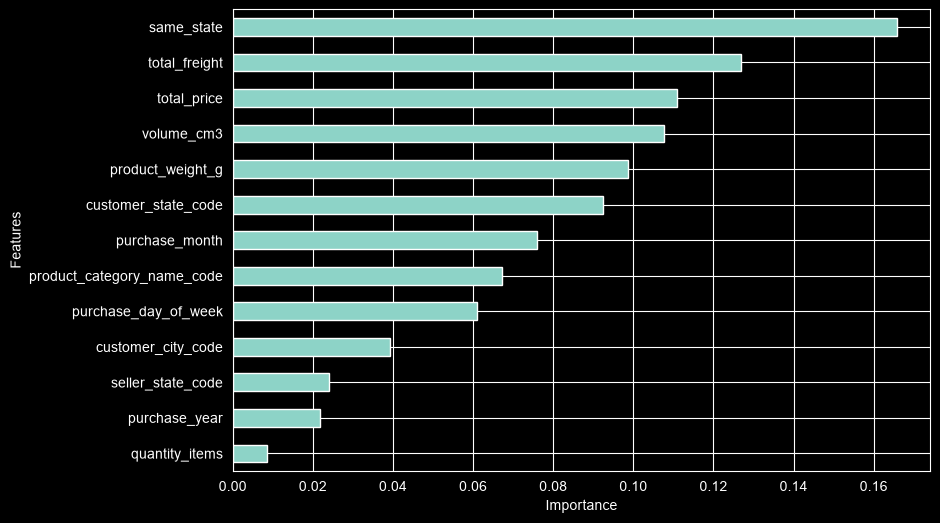

In [39]:
importances.sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## 7. Feature ablation

Checking whether the four weakest features (by importance) actually contribute to MAE or just add noise. Threshold: 0.02 days.

In [40]:
DROP = ['customer_city_code', 'seller_state_code', 'purchase_year', 'quantity_items']

FEATURES_SLIM = [f for f in FEATURES if f not in DROP]

model_rf_slim = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_slim.fit(train[FEATURES_SLIM], Y_train)
pred_rf_slim = model_rf_slim.predict(test[FEATURES_SLIM])

print("Features: ", len(FEATURES_SLIM))
print("MAE slim: ", round(mean_absolute_error(Y_test, pred_rf_slim), 3))
print("MAE full: ", round(mae_model_rf, 3))

Features:  9
MAE slim:  4.533
MAE full:  4.752


Dropped the four weakest features (customer_city, seller_state, purchase_year, quantity_items).
 MAE improved from 4.752 to 4.533. Weak features were adding noise to the splits.